# Setup

In [1]:
import json
import os
import re
import sys
from collections import defaultdict
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots
import seaborn as sns
import torch
from datasets import load_dataset
from matplotlib import font_manager
from sklearn.metrics import f1_score, cohen_kappa_score
from krippendorff import alpha
from transformers import AutoModelForSequenceClassification, AutoTokenizer

sys.path.append("../src")
from common import modify_last_character, clean_text

In [2]:
output_dir = "/home/slim/dpo-rhlf-paraphrase-types/out/plots"
os.chdir("/home/slim/dpo-rhlf-paraphrase-types")

annotation_file = "/home/slim/dpo-rhlf-paraphrase-types/out/gen-models/project-6-at-2024-11-18-12-03-5e87f640.json"
# with 2 annotators
annotation_file = "/home/slim/dpo-rhlf-paraphrase-types/out/gen-models/project-6-at-2024-12-10-11-38-7c4f3e10.json"
evaluation_file = "/home/slim/dpo-rhlf-paraphrase-types/out/gen-models/generated_paraphrases_Llama-3.1-8B_2024-11-15.json"

with open(annotation_file, 'r') as f:
    annotations_data = json.load(f)
with open(evaluation_file, 'r') as f:
    evaluations_data = json.load(f)

TOP_10_PARAPHRASE_TYPES = [
    "addition/deletion", 
    "change of order",
    "derivational changes",
    "inflectional changes",
    "punctuation changes",
    "same polarity substitution (contextual)",
    "semantic based",
    "spelling changes",
    "subordination and nesting changes",
    "synthetic/analytic substitution",
]

# Create a mapping from original types to their formatted names
PARAPHRASE_TYPE_MAPPING = {
    "additiondeletion": "Addition/Deletion",
    "addition/deletion": "Addition/Deletion",
    "AdditionDeletion": "Addition/Deletion",
    "change of order": "Change of order",
    "derivational changes": "Derivational Changes",
    "inflectional changes": "Inflectional Changes",
    "punctuation changes": "Punctuation Changes",
    "same polarity substitution (contextual)": "Same Polarity Substitution (contextual)",
    "semantic based": "Semantic Based",
    "semantic-based": "Semantic Based",
    "Semantic-based": "Semantic Based",
    "spelling changes": "Spelling Changes",
    "subordination and nesting changes": "Subordination and Nesting Changes",
    "syntheticanalytic substitution": "Synthetic/Analytic Substitution",
    "synthetic/analytic substitution": "Synthetic/Analytic Substitution",
    "Syntheticanalytic substitution": "Synthetic/Analytic Substitution",
    "Synthetic/analytic substitution": "Synthetic/Analytic Substitution",
}


def add_line_breaks(text, n=2):
    # Add a custom line break for "synthetic/analytic substitution"
    if text == "Synthetic/Analytic Substitution":
        return "Synthetic/Analytic\nsubstitution"
    if text == "same polarity substitution (contextual)":
        return "Same polarity\nsubstitution (cont.)"

    # Otherwise, split the text into words and add line breaks every `n` words
    words = text.split(" ")
    lines = [" ".join(words[i : i + n]) for i in range(0, len(words), n)]
    return "\n".join(lines)




In [3]:
%matplotlib inline
width = 6.25  # onecolumn-format
width2 = 3.06 # twocolumn-format
#aspect_ratio = (1 + 5**0.5) / 2  # golden ratio
aspect_ratio = np.sqrt(2)  # DIN A
height = width / aspect_ratio
heigth2 = width2 / aspect_ratio 

libertine_path = "/usr/share/fonts/opentype/linux-libertine/LinLibertine_R.otf"

font_dirs = [
    "/usr/share/fonts/opentype/linux-libertine"
]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

plt.style.use(["science", "no-latex"])
sns.set_palette("colorblind")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"], # ACM fonts: ["Linux Biolinum O", "Linux Biolinum", "Biolinum"]
    "figure.figsize": (width, height),
    "figure.dpi": 300,
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "figure.titlesize": 8,
    "legend.fontsize": 8,
    "ytick.labelsize": 8,
    "xtick.labelsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.top": False,
    "ytick.right": False,
    "axes.linewidth": 0.5,
})

In [4]:
print(heigth2)
print(height)

2.1637467504308354
4.419417382415921


In [5]:
# Get the colorblind palette
palette = sns.color_palette("colorblind")

# Convert to hex codes
from matplotlib.colors import to_hex, to_rgb

hex_colors = [to_hex(color) for color in palette]
rgb_colors = [to_rgb(color) for color in palette]

print(hex_colors)  # List of hex codes
print(rgb_colors)  # List of RGB values


['#0173b2', '#de8f05', '#029e73', '#d55e00', '#cc78bc', '#ca9161', '#fbafe4', '#949494', '#ece133', '#56b4e9']
[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00784313725490196, 0.6196078431372549, 0.45098039215686275), (0.8352941176470589, 0.3686274509803922, 0.0), (0.8, 0.47058823529411764, 0.7372549019607844), (0.792156862745098, 0.5686274509803921, 0.3803921568627451), (0.984313725490196, 0.6862745098039216, 0.8941176470588236), (0.5803921568627451, 0.5803921568627451, 0.5803921568627451), (0.9254901960784314, 0.8823529411764706, 0.2), (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]


# Dataset
## APTY

In [6]:
apty_ranked = load_dataset("worta/apty", "APTY-ranked")
apty_ranked = pd.DataFrame(apty_ranked["train"])


In [7]:
meta_df = pd.json_normalize(apty_ranked["meta"])
data = apty_ranked.drop(columns=["meta"]).reset_index(drop=True)
data = pd.concat([data, meta_df], axis=1)

# Extract the text from the nested dictionaries for 'chosen' and 'rejected'
data["original"] = data["original"].apply(
    lambda x: x["text"] if isinstance(x, dict) else str(x)
)
data["chosen"] = data["chosen"].apply(
    lambda x: x["text"] if isinstance(x, dict) else str(x)
)
data["rejected"] = data["rejected"].apply(
    lambda x: x["text"] if isinstance(x, dict) else str(x)
)

# Clean the text to fix encoding issues
data["original"] = data["original"].apply(clean_text)
data["chosen"] = data["chosen"].apply(clean_text)
data["rejected"] = data["rejected"].apply(clean_text)

# Strip whitespace
data["original"] = data["original"].str.strip()
data["chosen"] = data["chosen"].str.strip()
data["rejected"] = data["rejected"].str.strip()

# Modify the last character according to the rules
data["original"] = data["original"].apply(modify_last_character)
data["chosen"] = data["chosen"].apply(modify_last_character)
data["rejected"] = data["rejected"].apply(modify_last_character)

# Drop duplicates
data = data.drop_duplicates(subset=["original", "chosen", "rejected"])

In [8]:
# Create DataFrames from both counts
apt_total_counts = data["APT"].value_counts()
apt_unique_originals = data.groupby('APT')['original'].nunique()

# Combine into single DataFrame
combined_counts = pd.DataFrame({
    'Total APT Occurrences': apt_total_counts,
    'Unique Original Sentences': apt_unique_originals
})

# Sort by index (APT) alphabetically
combined_counts = combined_counts.sort_index()

latex_combined_counts = combined_counts.to_latex(
    float_format=lambda x: '%.0f' % x,  # No decimals for counts
    caption='Frequency of paraphrase types in APTY dataset',
    label='tab:dataset_apty'
)

print(latex_combined_counts)

\begin{table}
\caption{Frequency of paraphrase types in APTY dataset}
\label{tab:dataset_apty}
\begin{tabular}{lrr}
\toprule
 & Total APT Occurrences & Unique Original Sentences \\
APT &  &  \\
\midrule
AdditionDeletion & 40 & 9 \\
Change of order & 60 & 10 \\
Derivational Changes & 22 & 6 \\
Inflectional Changes & 12 & 7 \\
Punctuation changes & 28 & 9 \\
Same Polarity Substitution (contextual) & 56 & 10 \\
Semantic based & 59 & 10 \\
Spelling changes & 31 & 9 \\
Subordination and nesting changes & 18 & 5 \\
Syntheticanalytic substitution & 7 & 5 \\
\bottomrule
\end{tabular}
\end{table}



## ETPC

In [9]:
etpc = load_dataset("jpwahle/etpc")
etpc = pd.DataFrame(etpc["train"])

In [10]:
# Count both total and unique occurrences
total_counts = []
unique_counts = []

for types_list in etpc["paraphrase_types"]:
    # Count all occurrences for total
    total_counts.extend(types_list)
    # Count unique occurrences per row
    unique_counts.extend(set(types_list))

# Create Series for both counts
total_freq = pd.Series(total_counts).value_counts()
unique_freq = pd.Series(unique_counts).value_counts()

# Map standardized names
total_freq.index = total_freq.index.map(lambda x: PARAPHRASE_TYPE_MAPPING.get(x, x))
unique_freq.index = unique_freq.index.map(lambda x: PARAPHRASE_TYPE_MAPPING.get(x, x))

# Combine into DataFrame
comparison_df = pd.DataFrame({
    'Total Occurrences': total_freq,
    'Unique Occurrences': unique_freq
})

latex_table = comparison_df.to_latex(
    float_format=lambda x: '%.0f' % x,  # No decimals for counts
    caption='Frequency of paraphrase types in ETPC dataset',
    label='tab:dataet_etpc'
)

print(latex_table)

\begin{table}
\caption{Frequency of paraphrase types in ETPC dataset}
\label{tab:dataet_etpc}
\begin{tabular}{lrr}
\toprule
 & Total Occurrences & Unique Occurrences \\
\midrule
Addition/Deletion & 5722 & 2988 \\
Change of format & 240 & 207 \\
Change of order & 860 & 766 \\
Converse substitution & 43 & 42 \\
Coordination changes & 48 & 47 \\
Derivational Changes & 187 & 181 \\
Diathesis alternation & 162 & 161 \\
Direct/indirect style alternations & 66 & 66 \\
Ellipsis & 66 & 64 \\
Entailment & 81 & 81 \\
Identity & 3878 & 3870 \\
Inflectional Changes & 613 & 544 \\
Modal Verb Changes & 184 & 180 \\
Negation switching & 20 & 20 \\
Non-paraphrase & 842 & 605 \\
Opposite polarity substitution (contextual) & 15 & 12 \\
Opposite polarity substitution (habitual) & 4 & 4 \\
Punctuation changes & 833 & 748 \\
Same Polarity Substitution (contextual) & 4173 & 2511 \\
Same Polarity Substitution (habitual) & 840 & 681 \\
Same Polarity Substitution (named ent.) & 536 & 448 \\
Semantic based & 337

# Results

## Effectiveness of DPO and RHLF in Paraphrase Generation

### Llama-2


In [11]:
# Load the JSON data
with open(
    "/home/slim/dpo-rhlf-paraphrase-types/out/gen-models/project-5-at-2024-10-21-12-25-522ea966.json",
    "r",
) as file:
    data = json.load(file)

# Dictionary to store counts for each model
model_results = defaultdict(lambda: {"yes": 0, "total": 0})

# Iterate through each entry in the JSON data
for entry in data:
    kind = entry["data"]["Kind"]
    # Check the "APT" choice value in the annotations
    for annotation in entry["annotations"]:
        for result in annotation["result"]:
            if result["from_name"] == "APT":
                choice = result["value"]["choices"][0]
                model_results[kind]["total"] += 1
                if choice == "Yes":
                    model_results[kind]["yes"] += 1

# Calculate accuracy for each model
apt_percentages = {
    model: (counts["yes"] / counts["total"]) * 100
    for model, counts in model_results.items()
}

# Create a DataFrame for better formatting
df = pd.DataFrame({
    'Model': list(apt_percentages.keys()),
    'Accuracy (%)': list(apt_percentages.values())
})

# Convert to LaTeX table with formatting
latex_table = df.to_latex(
    index=False,
    float_format=lambda x: '%.1f' % x,
    caption='Accuracy of different models in generating specified paraphrase types',
    label='tab:model_accuracy'
)

print(latex_table)


\begin{table}
\caption{Accuracy of different models in generating specified paraphrase types}
\label{tab:model_accuracy}
\begin{tabular}{lr}
\toprule
Model & Accuracy (%) \\
\midrule
base_model & 12.4 \\
etpc_model & 11.8 \\
dpo_model & 35.3 \\
\bottomrule
\end{tabular}
\end{table}



In [12]:
# Dictionary to store counts for each (model, APT) pair
results = defaultdict(lambda: {"yes": 0, "total": 0})

# Iterate through each entry in the JSON data
for entry in data:
    # Ensure entry is a dictionary before processing
    if isinstance(entry, dict):
        kind = entry.get("data", {}).get("Kind")
        apt_value = entry.get("data", {}).get("APT")

        # Proceed only if both kind and apt_value are found
        if kind and apt_value:
            annotations = entry.get("annotations", [])

            # Check if there are annotations
            if annotations:
                for annotation in annotations:
                    results_found = annotation.get("result", [])

                    # Iterate through each result within the annotation
                    for result in results_found:
                        from_name = result.get("from_name")

                        # Focus on results where from_name is "APT"
                        if from_name == "APT":
                            choice = result.get("value", {}).get("choices", [None])[0]

                            # Check if the choice is valid
                            if choice:
                                results[(kind, apt_value)]["total"] += 1
                                if choice == "Yes":
                                    results[(kind, apt_value)]["yes"] += 1

# Calculate accuracy for each (model, APT) pair
apt_percentages = {
    (model, apt): (counts["yes"] / counts["total"]) * 100
    for (model, apt), counts in results.items()
    if counts["total"] > 0  # Avoid division by zero
}

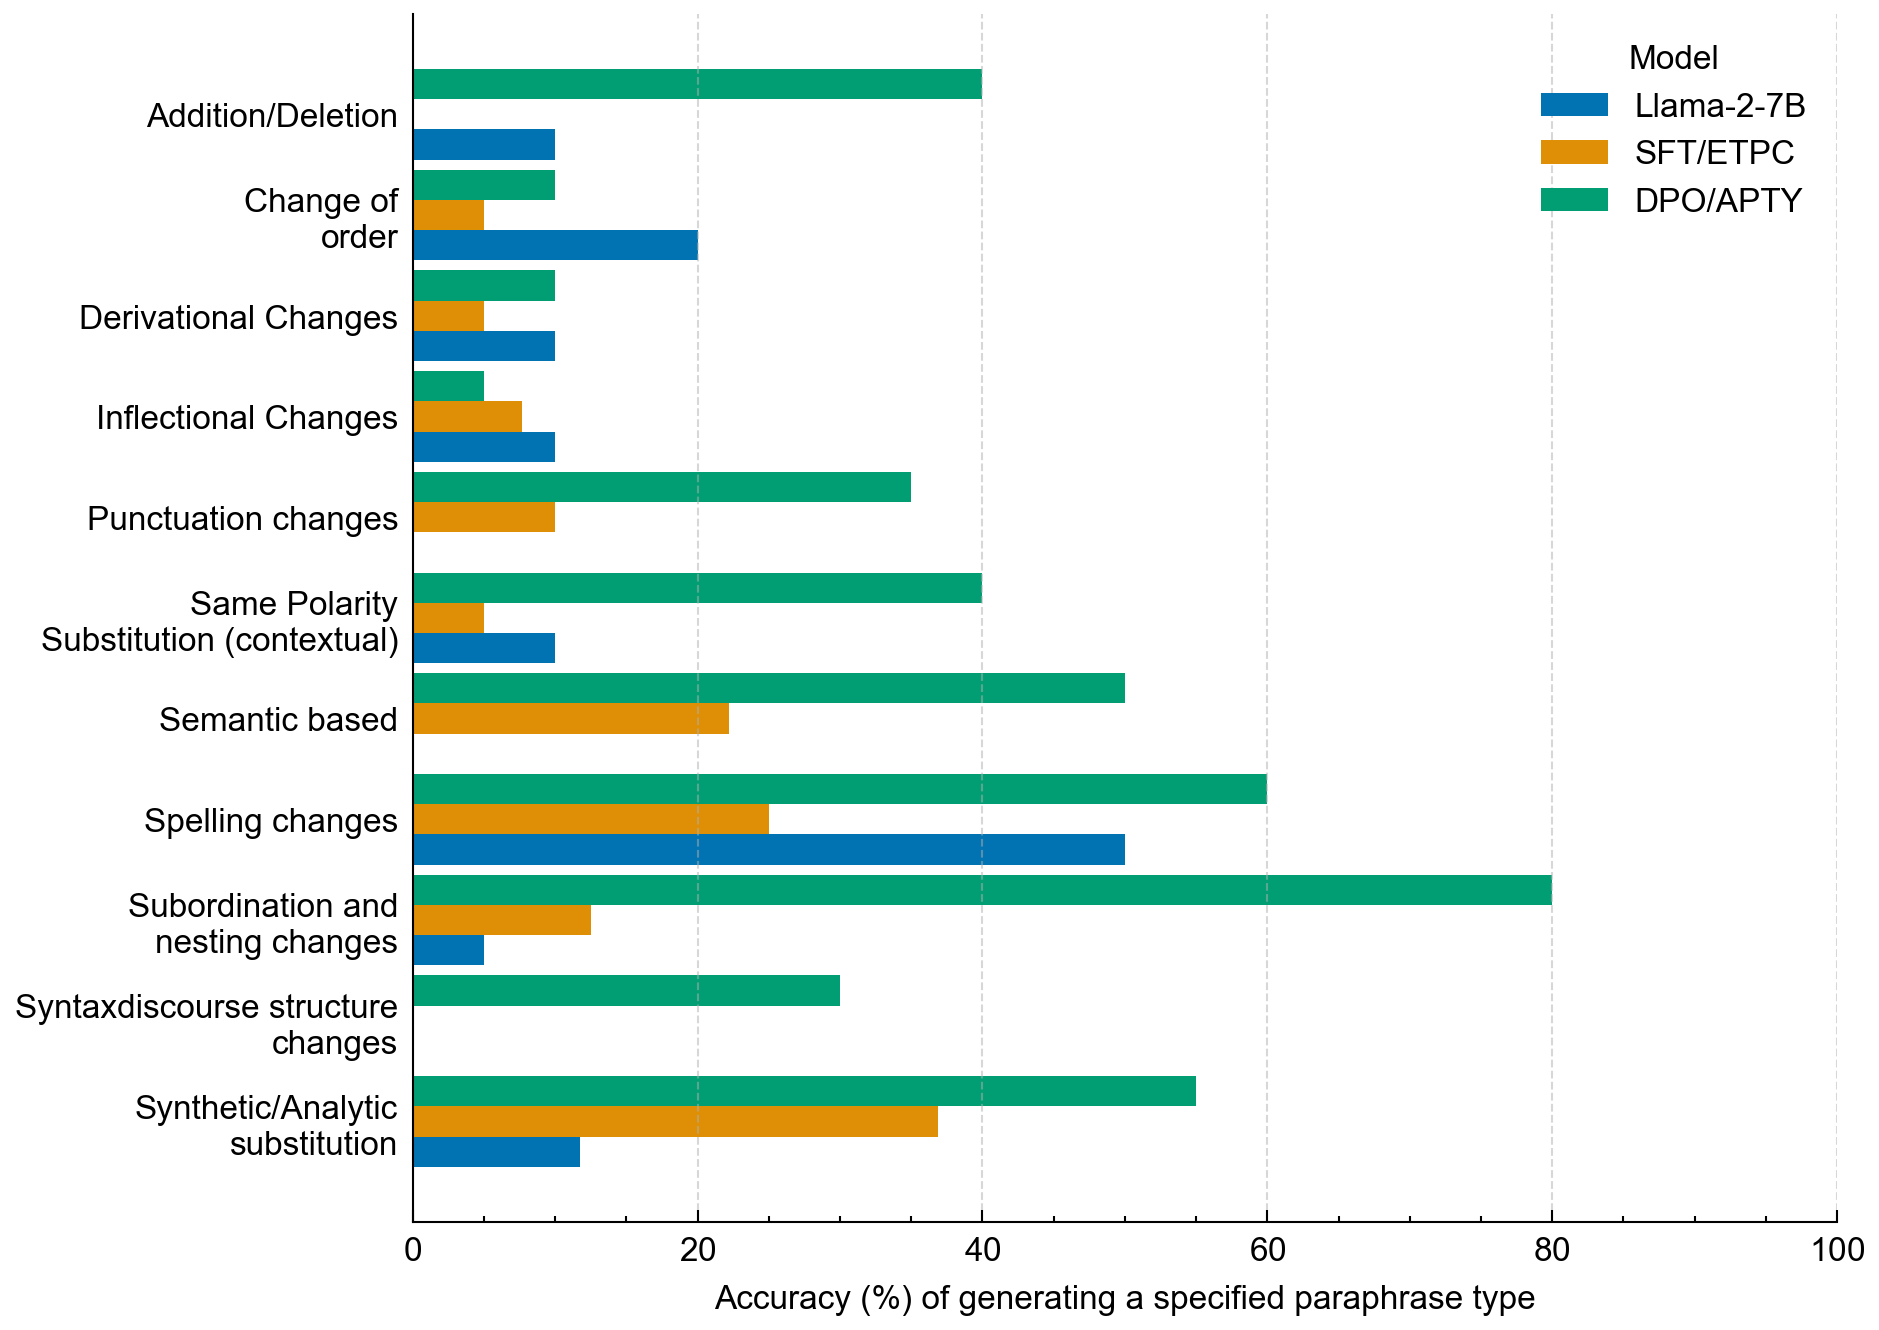

In [13]:
# Create a set of unique APT values and models in the specified order
apt_values = set(apt for _, apt in apt_percentages.keys())
models = ["base_model", "etpc_model", "dpo_model"]  # Ordered list of models
model_labels = {
    "base_model": "Llama-2-7B",
    "etpc_model": "SFT/ETPC",
    "dpo_model": "DPO/APTY",
}


# Create a dictionary to hold accuracy values for each model across APTs
model_accuracies = {
    model: [apt_percentages.get((model, apt), 0) for apt in apt_values]
    for model in models
}

mapped_apt_values = {PARAPHRASE_TYPE_MAPPING.get(apt, apt) for apt in apt_values}
sorted_apt_values = sorted(mapped_apt_values, reverse=True)
sorted_apt_values = [add_line_breaks(apt, n=2) for apt in sorted_apt_values]

# Create data for plotting
y = np.arange(len(sorted_apt_values))  # the label locations for the y-axis
width = 0.3  # the width of the bars

# Create the plot
fig, ax = plt.subplots(constrained_layout=True)

# Plot each model's accuracy as a separate set of horizontal bars
for i, model in enumerate(models):
    plt.barh(
        y + i * width, model_accuracies[model], height=width, label=model_labels[model]
    )

# Add labels and title
plt.xlabel("Accuracy (%) of generating a specified paraphrase type")
ax.set_yticks(y + width * (len(models) - 1) / 2, labels=sorted_apt_values)
plt.xlim(0, 100)
plt.legend(title="Model")
plt.grid(alpha=0)
plt.grid(axis="x", alpha=0.5, linestyle="--")

ax.tick_params(axis="y", which="both", left=False, right=False)

output_path = os.path.join(output_dir, "llama2_type_ranking.pdf")
plt.savefig(output_path, dpi=300)

### Llama-3.1


In [14]:
from scipy.stats import f_oneway

def calculate_accuracy(data):
    # Initialize result dictionary
    results = {}
    
    # Process data to calculate accuracies
    for item in data:
        if item['data'].get('dataset') != 'APTY':
            continue
        apt_type = item['data'].get('APT')
        if not apt_type:
            continue
        
        mapped_apt = PARAPHRASE_TYPE_MAPPING.get(apt_type, apt_type)
        if mapped_apt not in results:
            results[mapped_apt] = {
                'Llama-3.1-8B': {'good': 0, 'total': 0},
                'SFT/ETPC': {'good': 0, 'total': 0},
                'DPO/APTY': {'good': 0, 'total': 0},
                'IPO/APTY': {'good': 0, 'total': 0}
            }
            
        for annotation in item['annotations']:
            for result in annotation['result']:
                if result['from_name'] == 'annot':
                    ranker = result['value'].get('ranker', {})
                    model_map = {
                        '0': 'Llama-3.1-8B',
                        '1': 'SFT/ETPC',
                        '2': 'DPO/APTY',
                        '3': 'IPO/APTY'
                    }
                    
                    # Count good rankings (a+b) and total annotations
                    for model_id in model_map:
                        model_name = model_map[model_id]
                        good_count = len([x for x in ranker.get('a', []) + ranker.get('b', []) if x == model_id])
                        total_count = sum(1 for lst in ranker.values() if model_id in lst)
                        results[mapped_apt][model_name]['good'] += good_count
                        results[mapped_apt][model_name]['total'] += total_count

    # Convert to DataFrame
    df_data = []
    for apt, models in results.items():
        row = {'APT': add_line_breaks(apt, n=2)}  # Apply line breaks
        for model, counts in models.items():
            accuracy = counts['good']/counts['total'] if counts['total'] > 0 else 0
            row[model] = accuracy*100
        df_data.append(row)
    
    df = pd.DataFrame(df_data)   
    df = df.sort_values(by='APT', ascending=False)
    
    return df

llama3_accuracy = calculate_accuracy(annotations_data)

# Perform ANOVA test
anova_results = f_oneway(
    llama3_accuracy['Llama-3.1-8B'],
    llama3_accuracy['SFT/ETPC'],
    llama3_accuracy['DPO/APTY'],
    llama3_accuracy['IPO/APTY']
)

print(f"ANOVA F-statistic: {anova_results.statistic}")
print(f"ANOVA p-value: {anova_results.pvalue}")

if anova_results.pvalue < 0.05:
    print("There is a statistically significant difference in accuracies between the models.")
else:
    print("There is no statistically significant difference in accuracies between the models.")


ANOVA F-statistic: 49.38906524990428
ANOVA p-value: 7.658089985883059e-13
There is a statistically significant difference in accuracies between the models.


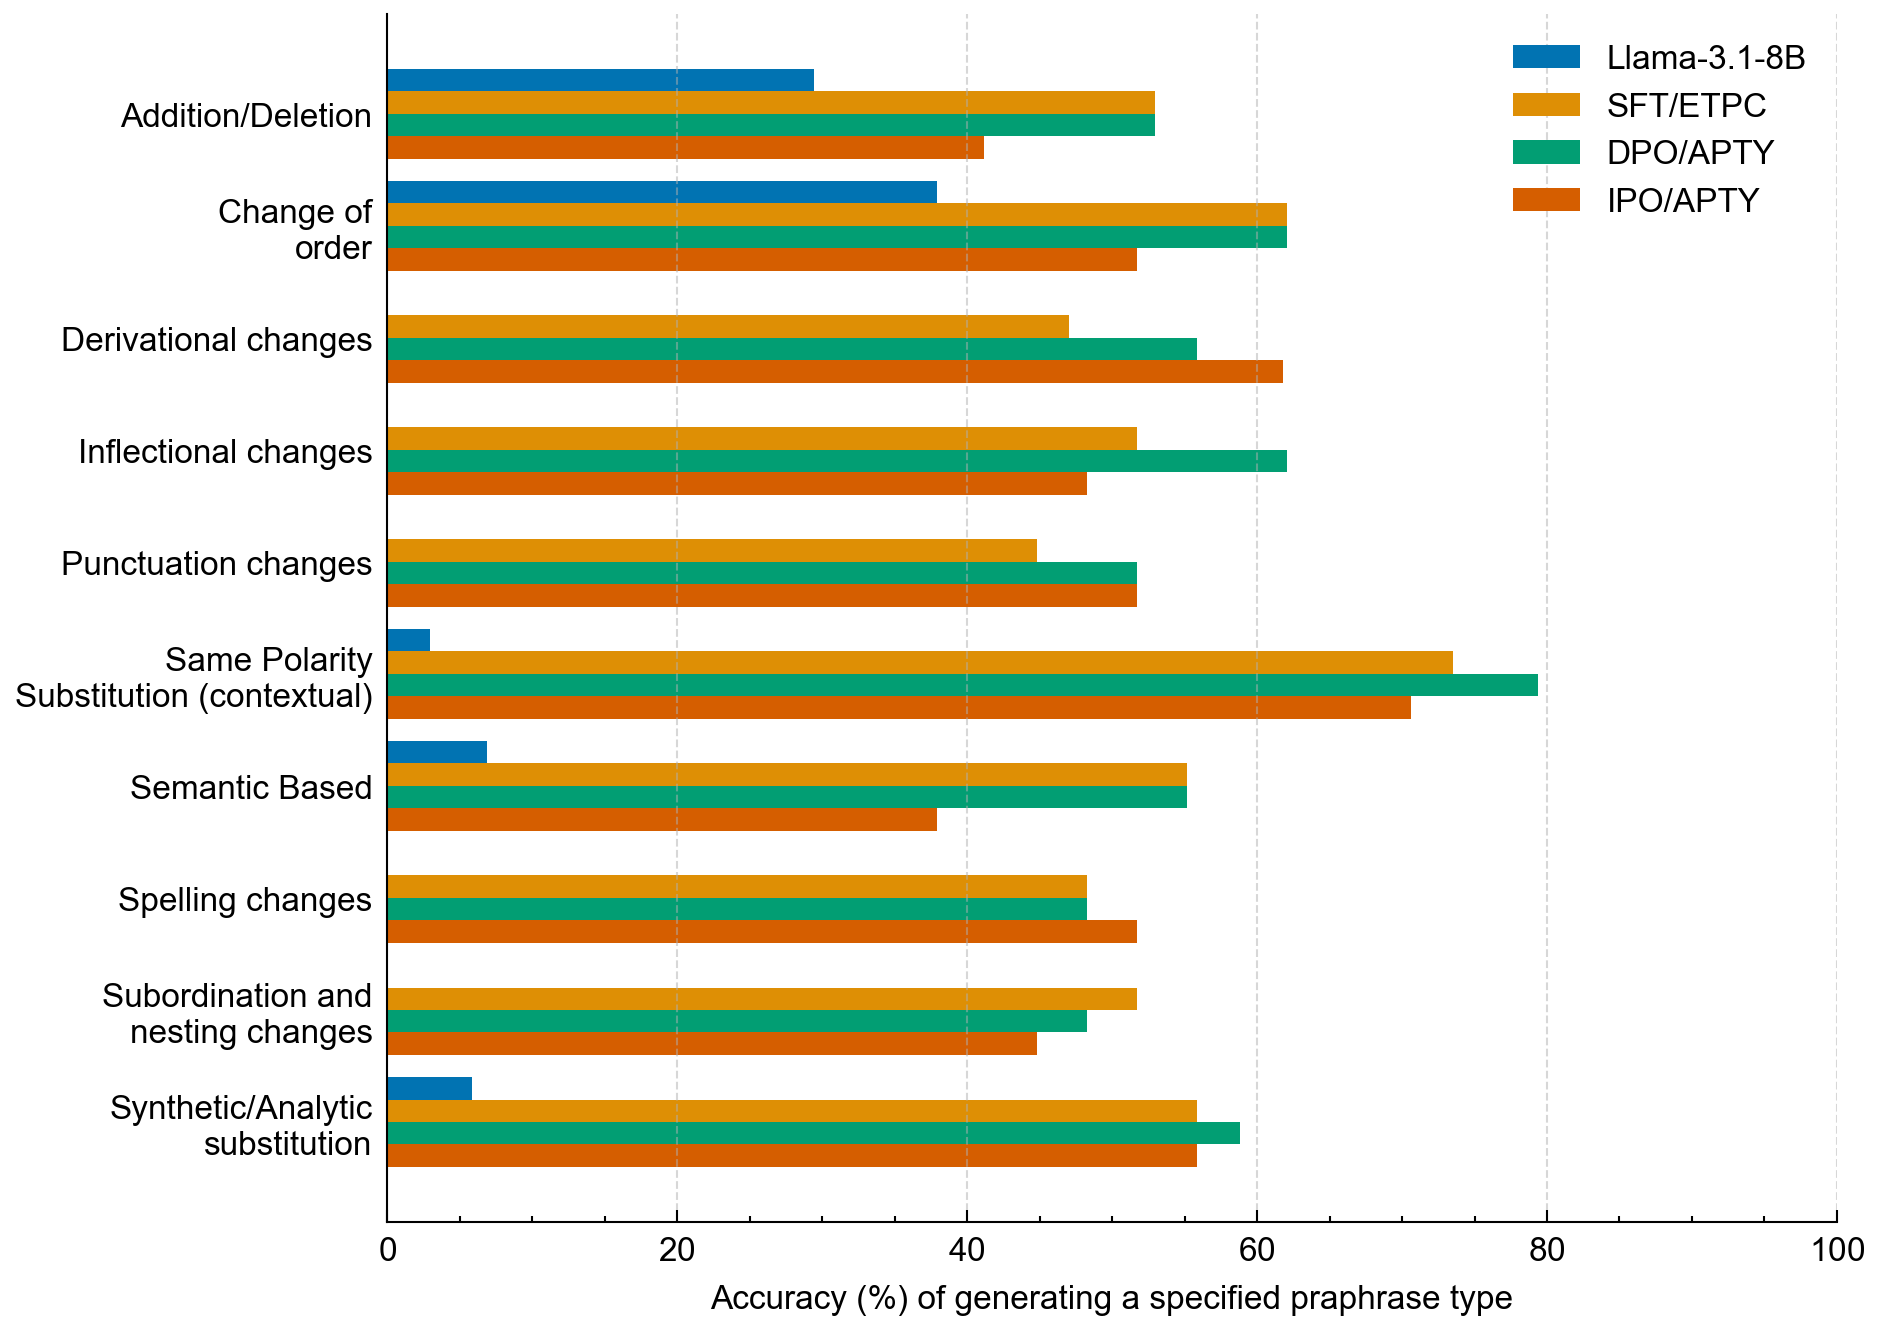

In [15]:
# Create plot
fig, ax = plt.subplots(constrained_layout=True)

models = ['Llama-3.1-8B', 'SFT/ETPC', 'DPO/APTY', 'IPO/APTY']
x = np.arange(len(llama3_accuracy['APT']))
width = 0.2

for i, model in enumerate(models):
    ax.barh(x + (len(models) - 1 - i) *width, llama3_accuracy[model], width, label=model)

ax.set_yticks(x + width*1.5)
ax.set_yticklabels(llama3_accuracy['APT'])
ax.tick_params(axis="y", which="both", left=False, right=False)
ax.set_xlabel("Accuracy (%) of generating a specified praphrase type")
plt.xlim(0, 100)
plt.grid(alpha=0)
plt.grid(axis="x", alpha=0.5, linestyle="--")
plt.legend()

output_path = os.path.join(output_dir, "llama3_type_ranking.pdf")
plt.savefig(output_path, dpi=300)

In [16]:
mean_accuracy_by_model = llama3_accuracy.drop(columns=["APT"]).mean()
std_accuracy_by_model = llama3_accuracy.drop(columns=["APT"]).std()

# Combine mean and standard deviation into a single DataFrame
accuracy_stats = pd.DataFrame({
    'Mean Accuracy': mean_accuracy_by_model,
    'Standard Deviation': std_accuracy_by_model
})

latex_accuracy = accuracy_stats.to_latex(
    float_format=lambda x: '%.0f' % x,  # Two decimals for mean and std
    caption="Comparison of model performance in generating paraphrases: The table shows each model's mean accuracy and standard deviation in generating paraphrases of specific types. Higher accuracy reflects better alignment with the target paraphrase type. The DPO/APTY model achieves the highest mean accuracy, with moderate variation in performance across types, as indicated by the standard deviation.",
    label='tab:accuracy'
)

print(latex_accuracy)

\begin{table}
\caption{Comparison of model performance in generating paraphrases: The table shows each model's mean accuracy and standard deviation in generating paraphrases of specific types. Higher accuracy reflects better alignment with the target paraphrase type. The DPO/APTY model achieves the highest mean accuracy, with moderate variation in performance across types, as indicated by the standard deviation.}
\label{tab:accuracy}
\begin{tabular}{lrr}
\toprule
 & Mean Accuracy & Standard Deviation \\
\midrule
Llama-3.1-8B & 8 & 14 \\
SFT/ETPC & 54 & 8 \\
DPO/APTY & 57 & 9 \\
IPO/APTY & 52 & 10 \\
\bottomrule
\end{tabular}
\end{table}



In [17]:
def calculate_agreement(annotations_data):
    annot_data = []  # For a/b/d categories
    rank_data = []   # For 1-4 categories
    
    # Filter to only include items with exactly 2 annotations
    two_annot_items = [item for item in annotations_data if len(item['annotations']) == 2]
    
    for item in two_annot_items:
        if len(item['annotations']) == 2:
            # Store both types of rankings for each annotator
            annotator_rankings = {
                '2': {'annot': {}, 'rank': {}},
                '22': {'annot': {}, 'rank': {}}
            }
            
            # Extract rankings from both annotators
            for annotation in item['annotations']:
                annotator = str(annotation['completed_by'])
                for result in annotation['result']:
                    ranker = result['value']['ranker']
                    
                    if result['from_name'] == 'annot':
                        # Extract a/b/d rankings
                        for category in ['a', 'b', 'd']:
                            for model_idx in ranker.get(category, []):
                                annotator_rankings[annotator]['annot'][model_idx] = category
                    
                    elif result['from_name'] == 'rank':
                        # Extract 1-4 rankings
                        for category in ['1', '2', '3', '4']:
                            for model_idx in ranker.get(category, []):
                                annotator_rankings[annotator]['rank'][model_idx] = category
            
            # Compare annotations between annotators
            model_indices = set(annotator_rankings['2']['annot'].keys()) & set(annotator_rankings['22']['annot'].keys())
            for idx in model_indices:
                if idx in annotator_rankings['2']['annot'] and idx in annotator_rankings['22']['annot']:
                    annot_data.append([
                        ['a', 'b', 'd'].index(annotator_rankings['2']['annot'][idx]),
                        ['a', 'b', 'd'].index(annotator_rankings['22']['annot'][idx])
                    ])
                
                if idx in annotator_rankings['2']['rank'] and idx in annotator_rankings['22']['rank']:
                    rank_data.append([
                        int(annotator_rankings['2']['rank'][idx]),
                        int(annotator_rankings['22']['rank'][idx])
                    ])

    
    # Calculate agreement scores
    kappa_annot = cohen_kappa_score(np.array(annot_data)[:,0], np.array(annot_data)[:,1]) if annot_data else None
    alpha_rank = alpha(np.array(rank_data).T) if rank_data else None

    return {
        'kappa_annot': kappa_annot,  # Agreement on quality categories (a/b/d)
        'alpha_rank': alpha_rank     # Agreement on numerical rankings (1-4)
    }
    
def interpret_agreement(kappa=None, alpha=None):
    kappa_interpret = {
        (0.81, 1.00): "Almost perfect",
        (0.61, 0.80): "Substantial",
        (0.41, 0.60): "Moderate",
        (0.21, 0.40): "Fair",
        (0.01, 0.20): "Slight",
        (-1.00, 0.00): "Poor"
    }
    
    alpha_interpret = {
        (0.80, 1.00): "Good",
        (0.67, 0.80): "Tentative",
        (-1.00, 0.67): "Poor"
    }
    
    results = []
    if kappa is not None:
        for (lower, upper), label in kappa_interpret.items():
            if lower <= kappa <= upper:
                results.append(f"Kappa: {kappa:.3f} ({label} agreement)")
                break
                
    if alpha is not None:
        for (lower, upper), label in alpha_interpret.items():
            if lower <= alpha <= upper:
                results.append(f"Alpha: {alpha:.3f} ({label} agreement)")
                break
                
    return "\n".join(results)

# Add interpretation to output
agreement = calculate_agreement(annotations_data)

print(interpret_agreement(agreement['kappa_annot'], agreement['alpha_rank']))

Kappa: 0.690 (Substantial agreement)
Alpha: 0.631 (Poor agreement)


## Incorporating Human-Ranked Data for Improved Paraphrase Generation


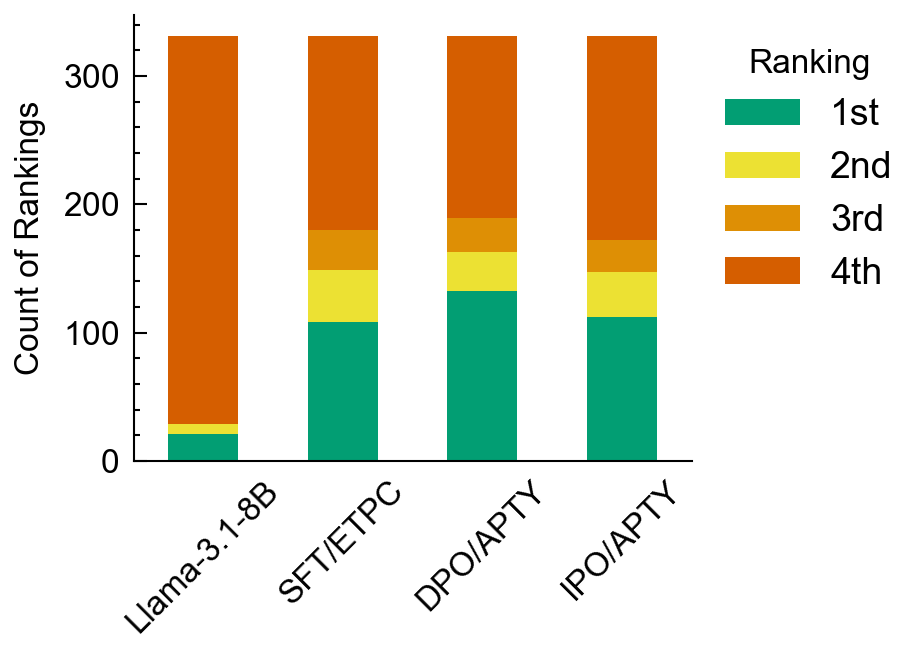

In [18]:
def analyze_rankings(data):
    # Initialize counters
    rank_counts = {
        'Llama-3.1-8B': {1: 0, 2: 0, 3: 0, 4: 0},
        'SFT/ETPC': {1: 0, 2: 0, 3: 0, 4: 0}, 
        'DPO/APTY': {1: 0, 2: 0, 3: 0, 4: 0},
        'IPO/APTY': {1: 0, 2: 0, 3: 0, 4: 0}
    }
    
    # Model ID mapping
    model_map = {
        '0': 'Llama-3.1-8B',
        '1': 'SFT/ETPC',
        '2': 'DPO/APTY', 
        '3': 'IPO/APTY'
    }

    # Count rankings
    for item in data:
        for annotation in item['annotations']:
            for result in annotation['result']:
                if result['from_name'] == 'rank':
                    ranker = result['value']['ranker']
                    for rank, model_ids in ranker.items():
                        if rank != '_':  # Skip empty rankings
                            rank_num = int(rank)
                            for model_id in model_ids:
                                if model_id in model_map:
                                    rank_counts[model_map[model_id]][rank_num] += 1

    # Convert to DataFrame
    df = pd.DataFrame(rank_counts).transpose()
    
    return df

# Create plot
def create_ranking_plot(df):
    fig, ax = plt.subplots(constrained_layout=True, figsize=(width2, heigth2))

    # Reorder the colors from the sns colorblind palette
    colors = sns.color_palette("colorblind")
    reordered_colors = [colors[2], colors[8], colors[1], colors[3]]  # Green, Blue, Orange

    df.plot(kind='bar', stacked=True, ax=ax, color=reordered_colors)
    
    ax.set_ylabel("Count of Rankings")
    ax.tick_params(axis="x", which="both", top=False, bottom=False, rotation=45)
    ax.tick_params(axis="y")
    
    ax.legend(title="Ranking", 
             labels=["1st", "2nd", "3rd", "4th"],
             bbox_to_anchor=(1.0, 1),
             loc='upper left',
             fontsize=9)
    plt.grid(alpha=0)

    
    return plt

# Load and process data
df = analyze_rankings(annotations_data)
plot = create_ranking_plot(df)

output_path = os.path.join(output_dir, "apt_ranking.pdf")
plt.savefig(output_path, dpi=300)

In [19]:
from scipy.stats import chi2_contingency

# Calculate the total count of rankings for each model
total_rankings = df.sum(axis=1)

# Calculate the percentage of each ranking for each model
percentage_rankings = df.div(total_rankings, axis=0) * 100

latex_percentage_rankings = percentage_rankings.to_latex(
    float_format=lambda x: '%.0f' % x,  # No decimals for percentages
    caption='Percentage of each ranking for each model',
    label='tab:percentage_rankings'
)

print(latex_percentage_rankings)
# Perform a statistical analysis to support the claim that DPO-trained models are ranked higher


# Create a contingency table
contingency_table = df.loc[['DPO/APTY', 'Llama-3.1-8B', 'SFT/ETPC', 'IPO/APTY']]

# Perform the Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2}")
print(f"P-value: {p}")

if p < 0.05:
    print("There is a statistically significant difference in rankings between the models.")
else:
    print("There is no statistically significant difference in rankings between the models.")

\begin{table}
\caption{Percentage of each ranking for each model}
\label{tab:percentage_rankings}
\begin{tabular}{lrrrr}
\toprule
 & 1 & 2 & 3 & 4 \\
\midrule
Llama-3.1-8B & 6 & 2 & 0 & 91 \\
SFT/ETPC & 33 & 12 & 9 & 46 \\
DPO/APTY & 40 & 9 & 8 & 43 \\
IPO/APTY & 34 & 11 & 8 & 48 \\
\bottomrule
\end{tabular}
\end{table}

Chi-Square Statistic: 220.14547895687332
P-value: 1.9505359124370147e-42
There is a statistically significant difference in rankings between the models.


## Correlation Between Automatic Metrics and Human Judgment


In [20]:
def get_mean_scores(evaluations_data):
    # Initialize dictionaries to store scores
    scores = {
        '0': {'rouge-1': [], 'rouge-2': [], 'rouge-l': [], 'bleu': []},  # Llama-3.1-8B
        '1': {'rouge-1': [], 'rouge-2': [], 'rouge-l': [], 'bleu': []},  # SFT/ETPC
        '2': {'rouge-1': [], 'rouge-2': [], 'rouge-l': [], 'bleu': []},  # DPO/APTY
        '3': {'rouge-1': [], 'rouge-2': [], 'rouge-l': [], 'bleu': []}   # IPO/APTY
    }
    
    # Extract scores for each model
    for item in evaluations_data:
        for model_output in item['List']:
            if 'evaluation' in model_output:
                model_id = str(model_output['id'])
                scores[model_id]['rouge-1'].append(model_output['evaluation']['rouge-1'])
                scores[model_id]['rouge-2'].append(model_output['evaluation']['rouge-2'])
                scores[model_id]['rouge-l'].append(model_output['evaluation']['rouge-l'])
                scores[model_id]['bleu'].append(model_output['evaluation']['bleu'])

    # Calculate means
    model_names = {
        '0': 'Llama-3.1-8B',
        '1': 'SFT/ETPC',
        '2': 'DPO/APTY',
        '3': 'IPO/APTY'
    }
    
    mean_scores = {}
    for model_id, metrics in scores.items():
        model_name = model_names[model_id]
        mean_scores[model_name] = {
            metric: round(np.mean(values) , 2) 
            for metric, values in metrics.items()
        }
    
    df = pd.DataFrame(mean_scores).T
    
    # Rename columns
    df.columns = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU']
    
    return df

# Calculate and display mean scores
mean_scores = get_mean_scores(evaluations_data)
latex_mean_scores = mean_scores.to_latex(
    float_format=lambda x: '%.2f' % x,  # No decimals for percentages
    caption='Mean Automatic Scores',
    label='tab:percentage_rankings'
)

print(latex_mean_scores)

\begin{table}
\caption{Mean Automatic Scores}
\label{tab:percentage_rankings}
\begin{tabular}{lrrrr}
\toprule
 & ROUGE-1 & ROUGE-2 & ROUGE-L & BLEU \\
\midrule
Llama-3.1-8B & 0.61 & 0.45 & 0.59 & 0.23 \\
SFT/ETPC & 0.68 & 0.59 & 0.67 & 0.41 \\
DPO/APTY & 0.67 & 0.58 & 0.66 & 0.40 \\
IPO/APTY & 0.66 & 0.56 & 0.65 & 0.38 \\
\bottomrule
\end{tabular}
\end{table}



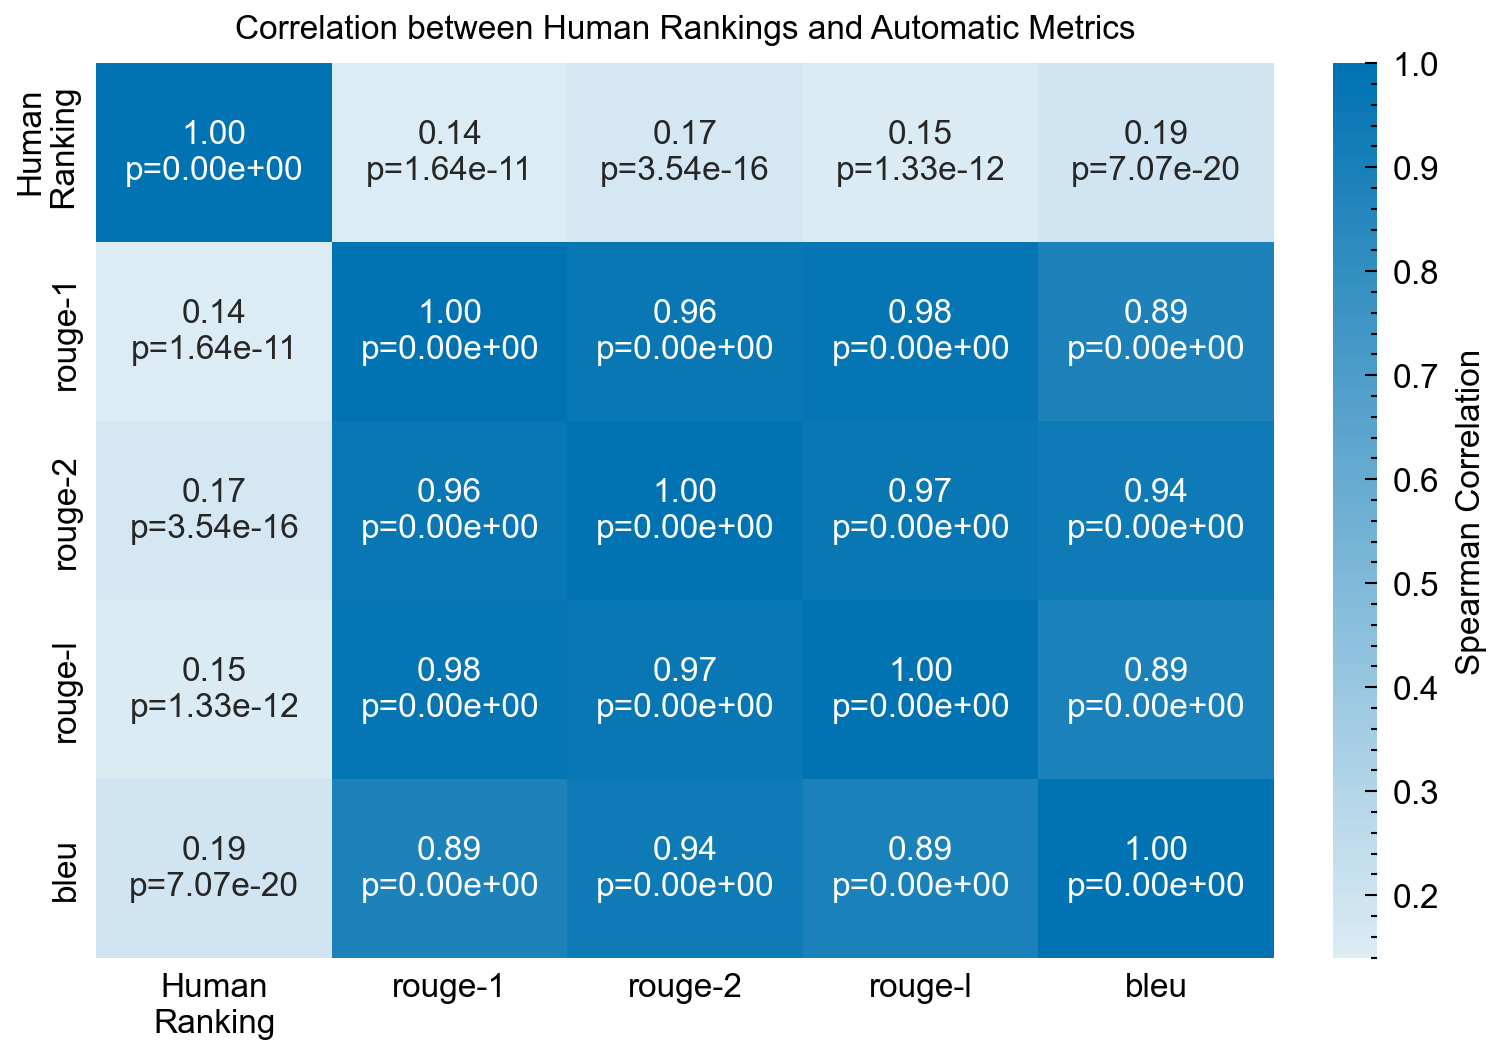

In [21]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def analyze_correlations():
    # Initialize data structures
    rankings_data = []

    # Process annotations
    for item in annotations_data:
        item_id = item["data"]["id"]

        # Extract rankings from annotations
        for annotation in item["annotations"]:
            for result in annotation["result"]:
                if result["from_name"] == "rank":  # Changed from 'annot' to 'rank'
                    rankings = result["value"]["ranker"]

                    # Convert rankings to scores (1=best, 4=worst)
                    for rank, model_ids in rankings.items():
                        if rank != "_":  # Skip empty rankings
                            rank_num = int(rank)
                            for model_id in model_ids:
                                rankings_data.append(
                                    {
                                        "id": item_id,
                                        "model": model_id,
                                        "rank": rank_num,  # Lower rank is better
                                    }
                                )

    rankings_df = pd.DataFrame(rankings_data)

    # Extract automatic metric scores
    scores_data = []
    for item in evaluations_data:
        item_id = item["id"]
        for model_output in item["List"]:
            if "evaluation" in model_output:
                scores_data.append(
                    {
                        "id": item_id,
                        "model": str(model_output["id"]),
                        "rouge-1": model_output["evaluation"]["rouge-1"],
                        "rouge-2": model_output["evaluation"]["rouge-2"],
                        "rouge-l": model_output["evaluation"]["rouge-l"],
                        "bleu": model_output["evaluation"]["bleu"],
                    }
                )

    scores_df = pd.DataFrame(scores_data)

    # Merge rankings and scores
    combined_df = pd.merge(rankings_df, scores_df, on=["id", "model"])

    # Calculate Spearman correlations and p-values
    metrics = ["rouge-1", "rouge-2", "rouge-l", "bleu"]
    corr_data = np.zeros((len(metrics) + 1, len(metrics) + 1))
    p_values = np.zeros((len(metrics) + 1, len(metrics) + 1))

    # Calculate correlation of human ranking with itself first - should be 1.0
    corr_data[0, 0], p_values[0, 0] = spearmanr(combined_df["rank"], combined_df["rank"])

    for i, metric in enumerate(metrics):
        # Negative correlation because lower rank is better
        corr, p_val = spearmanr(combined_df[metric], combined_df["rank"])
        corr_data[0, i + 1] = -corr
        p_values[0, i + 1] = p_val
        corr_data[i + 1, 0] = -corr
        p_values[i + 1, 0] = p_val

    # Calculate correlations and p-values between metrics
    for i, metric1 in enumerate(metrics):
        for j, metric2 in enumerate(metrics):
            corr, p_val = spearmanr(combined_df[metric1], combined_df[metric2])
            corr_data[i + 1, j + 1] = corr
            p_values[i + 1, j + 1] = p_val

    # Create correlation plot
    import matplotlib.colors as mcolors
    import seaborn as sns

    # Get colorblind palette colors
    colors = sns.color_palette("colorblind")

    # Create diverging colormap using a subset of colors
    # Using blue -> gray -> orange for negative -> zero -> positive
    colormap = mcolors.LinearSegmentedColormap.from_list(
        "colorblind_diverging",
        [colors[1], "#FFFFFF", colors[0]], 
        N=256
    )

    fig, ax = plt.subplots(constrained_layout=True, figsize=(5, 3.5))

    sns.heatmap(
        corr_data,
        xticklabels=["Human\nRanking"] + metrics,
        yticklabels=["Human\n Ranking"] + metrics,
        cmap=colormap,
        center=0,
        annot=[[f"{corr:.2f}\np={p:.2e}" for corr, p in zip(row_c, row_p)] 
               for row_c, row_p in zip(corr_data, p_values)],
        fmt="",
        cbar_kws={"label": "Spearman Correlation"},
    )

    plt.title("Correlation between Human Rankings and Automatic Metrics")
    ax.tick_params(axis="y", which="both", left=False, right=False)
    ax.tick_params(axis="x", which="both", top=False, bottom=False)

    return plt


# Create and save plot
plot = analyze_correlations()

output_path = os.path.join(output_dir, "correlation_matrix.pdf")
plt.savefig(output_path, dpi=300)

## New metric


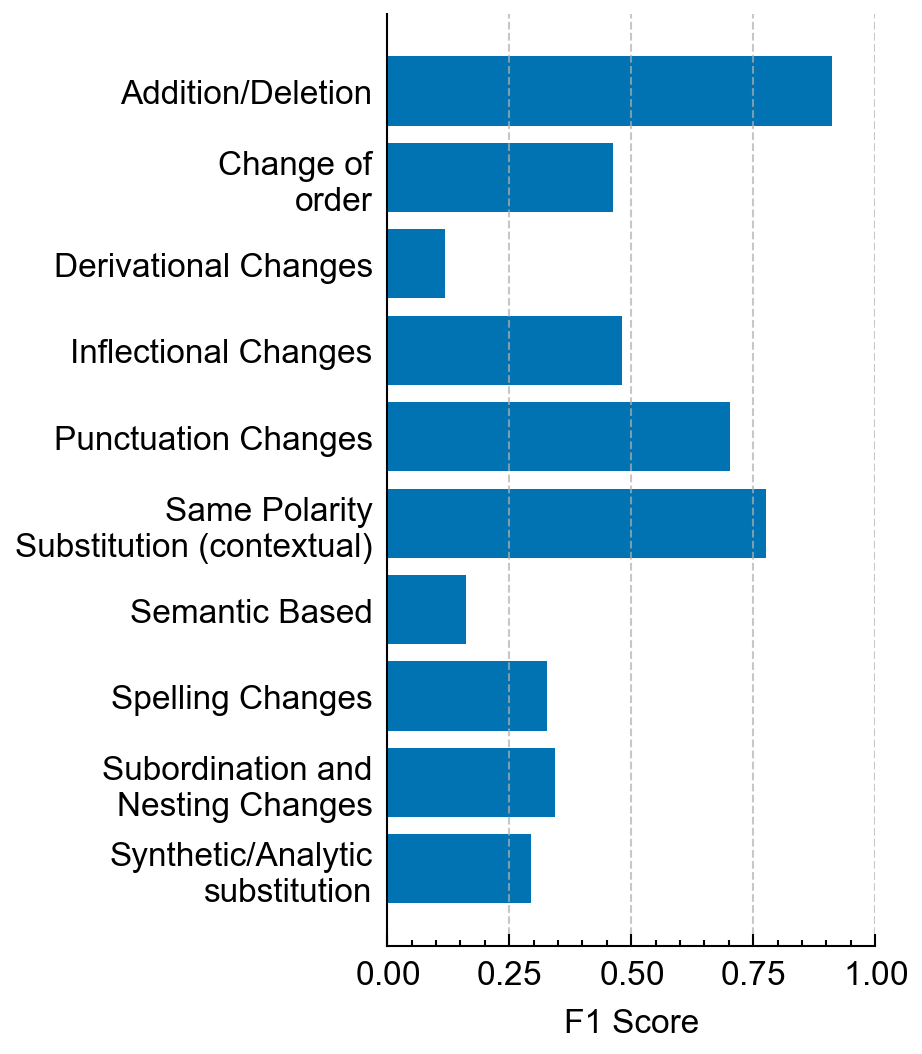

In [22]:
classification_data = pd.read_csv(
    "/home/slim/dpo-rhlf-paraphrase-types/out/cls-models/deberta-base_qqp_pd_ptd_results_hyperclass_20241024_161522.csv",
    skiprows=14,
)

classification_data["Paraphrase Type"] = (
    classification_data["Paraphrase Type"]
    .map(PARAPHRASE_TYPE_MAPPING)
    .fillna(classification_data["Paraphrase Type"])
)
classification_data["Paraphrase Type"] = classification_data["Paraphrase Type"].apply(
    lambda x: add_line_breaks(x, n=2)
)

# Extract F1 scores for each paraphrase type, excluding rows like 'micro avg', 'macro avg', etc.
paraphrase_f1_scores = classification_data[
    ~classification_data["Paraphrase Type"].str.contains("avg")
]
paraphrase_f1_scores = paraphrase_f1_scores.sort_values(
    by="Paraphrase Type", ascending=False
)

# Create the plot
fig, ax = plt.subplots(constrained_layout=True, figsize=(width2, 3.5))

plt.barh(paraphrase_f1_scores["Paraphrase Type"], paraphrase_f1_scores["F1-score"])

plt.xlabel(
    "F1 Score",
)
ax.tick_params(axis="x", which="both")  # Set x-axis labels to size
plt.xlim(0, 1)

plt.grid(axis="x", linestyle="--", alpha=0.7)

ax.tick_params(
    axis="y", which="both", left=False, right=False
)  # Remove tick marks on the y-axis

output_path = os.path.join(output_dir, "new_type_score.pdf")
plt.savefig(output_path, dpi=300)

In [23]:
import numpy as np
from scipy import stats
import pandas as pd

# Extract F1 scores and support from the report
classes = [
    "Addition/Deletion",
    "Change of order", 
    "Derivational Changes",
    "Inflectional Changes",
    "Punctuation Changes", 
    "Same Polarity Substitution (contextual)",
    "Semantic Based",
    "Spelling Changes",
    "Subordination and Nesting Changes",
    "Synthetic/Analytic substitution"
]

f1_scores = [
    0.9113924050632911,
    0.462882096069869,
    0.11940298507462686,
    0.4808362369337979,
    0.7019607843137254,
    0.7761989342806395,
    0.16216216216216217,
    0.3277777777777778,
    0.34459459459459457,
    0.29491525423728815
]

support = [1327.0, 303.0, 33.0, 130.0, 223.0, 1113.0, 63.0, 144.0, 94.0, 248.0]

# Calculate 95% confidence intervals
confidence_intervals = []
for f1, n in zip(f1_scores, support):
    # Using standard error formula for F1 score
    se = np.sqrt((f1 * (1-f1)) / n)
    ci = stats.norm.interval(0.95, loc=f1, scale=se)
    confidence_intervals.append(ci)

# Create results dataframe
results = pd.DataFrame({
    'Class': classes,
    'F1 Score': f1_scores,
    'CI Lower': [ci[0] for ci in confidence_intervals],
    'CI Upper': [ci[1] for ci in confidence_intervals],
    'Support': support
})

latex_results = results.to_latex(
        formatters={
        'Support': lambda x: f'{x:.0f}',
        'F1 Score': lambda x: f'{x:.2f}',
        'CI Lower': lambda x: f'{x:.2f}',
        'CI Upper': lambda x: f'{x:.2f}'
    },
    caption='Performance of the new paraphrase type detection model: The figure shows the F1 scores for detecting specific paraphrase types. The model performs best on types like Addition/Deletion (0.91), Same Polarity Substitution (0.77), and Punctuation Changes (0.70), while more complex paraphrase types exhibit lower accuracy',
    label='tab:f1_scores',
    index=False
)

print(latex_results)

\begin{table}
\caption{Performance of the new paraphrase type detection model: The figure shows the F1 scores for detecting specific paraphrase types. The model performs best on types like Addition/Deletion (0.91), Same Polarity Substitution (0.77), and Punctuation Changes (0.70), while more complex paraphrase types exhibit lower accuracy}
\label{tab:f1_scores}
\begin{tabular}{lrrrr}
\toprule
Class & F1 Score & CI Lower & CI Upper & Support \\
\midrule
Addition/Deletion & 0.91 & 0.90 & 0.93 & 1327 \\
Change of order & 0.46 & 0.41 & 0.52 & 303 \\
Derivational Changes & 0.12 & 0.01 & 0.23 & 33 \\
Inflectional Changes & 0.48 & 0.39 & 0.57 & 130 \\
Punctuation Changes & 0.70 & 0.64 & 0.76 & 223 \\
Same Polarity Substitution (contextual) & 0.78 & 0.75 & 0.80 & 1113 \\
Semantic Based & 0.16 & 0.07 & 0.25 & 63 \\
Spelling Changes & 0.33 & 0.25 & 0.40 & 144 \\
Subordination and Nesting Changes & 0.34 & 0.25 & 0.44 & 94 \\
Synthetic/Analytic substitution & 0.29 & 0.24 & 0.35 & 248 \\
\bottomrul

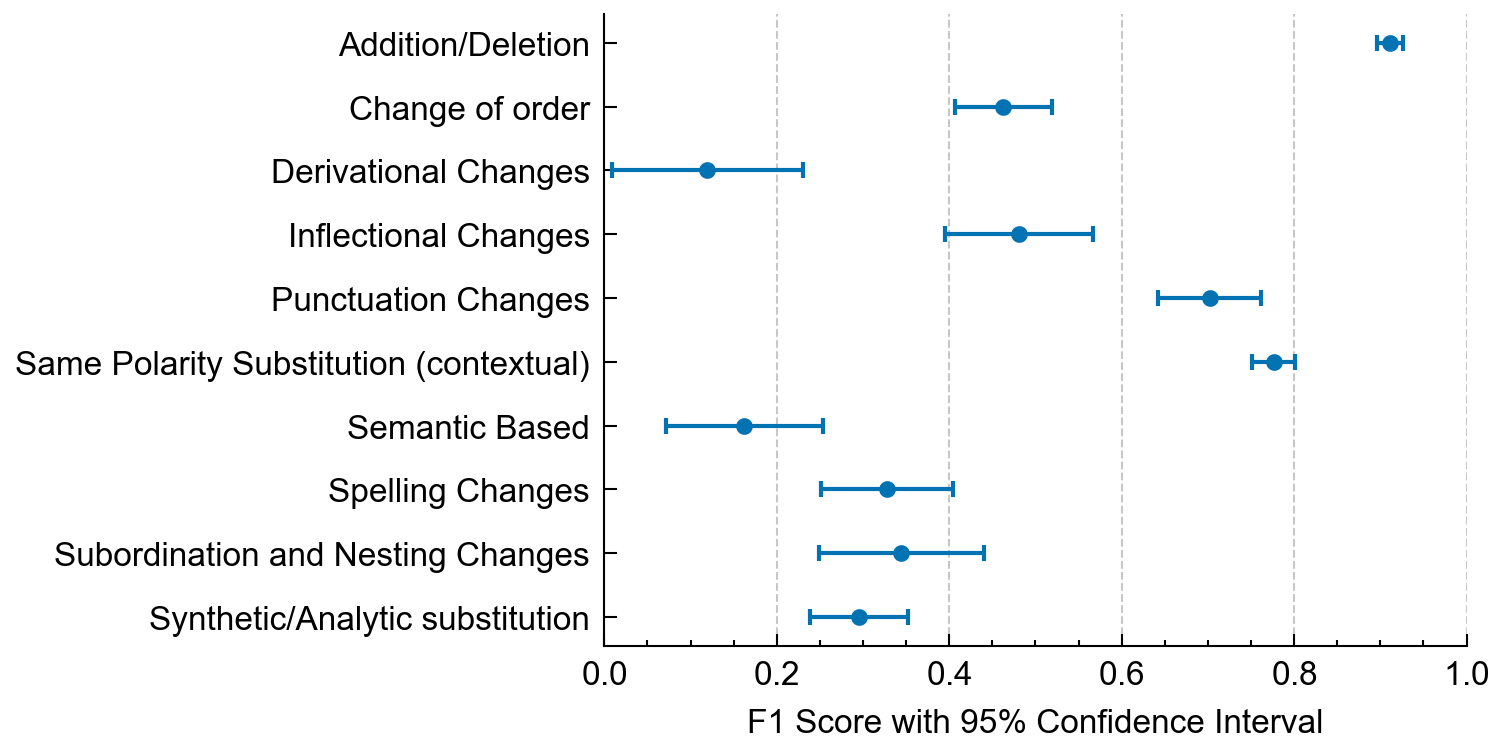

In [24]:
sorted_indices = np.argsort(classes)[::-1]  # reverse order
classes_sorted = [classes[i] for i in sorted_indices]
f1_scores_sorted = [f1_scores[i] for i in sorted_indices]
ci_sorted = [confidence_intervals[i] for i in sorted_indices]

xerr = [[f1 - ci[0] for f1, ci in zip(f1_scores_sorted, ci_sorted)],
        [ci[1] - f1 for f1, ci in zip(f1_scores_sorted, ci_sorted)]]

# Plot scatter with error bars
# Create plot
fig, ax = plt.subplots(constrained_layout=True, figsize=(5, 2.5))

y_pos = np.arange(len(classes_sorted))

ax.errorbar(f1_scores_sorted, y_pos,
           xerr=xerr,
           fmt='o',
           capsize=2,
           markersize=3,
           elinewidth=1,
           capthick=1)

# Customize plot
ax.set_yticks(y_pos)
ax.set_yticklabels(classes_sorted)
ax.set_xlabel('F1 Score with 95% Confidence Interval')
ax.set_xlim(0, 1)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.grid(axis="y", linestyle="--", alpha=0)
ax.tick_params(axis='y', which='minor', length=0)

output_path = os.path.join(output_dir, "new_type_scatter.pdf")
plt.savefig(output_path, dpi=300)
# Save plot
plt.show()

### Llama-2


In [25]:
TOP_10_PARAPHRASE_TYPES_llama2 = [
    "additiondeletion",
    "change of order",
    "derivational changes",
    "inflectional changes",
    "punctuation changes",
    "same polarity substitution (contextual)",
    "semantic based",
    "spelling changes",
    "subordination and nesting changes",
    "syntheticanalytic substitution",
]


class ParaphraseTypeEvaluator:
    def __init__(self, model_name: str, top_k: int = 10):
        self.model_name = model_name
        self.top_k = top_k
        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name, local_files_only=True
        )
        self.tokenizer = AutoTokenizer.from_pretrained(
            model_name, clean_up_tokenization_spaces=True
        )
        self.model.eval()
        self.normalized_top_10_types = [
            ptype.strip().lower() for ptype in TOP_10_PARAPHRASE_TYPES_llama2
        ]

    def preprocess_apt(self, apt: str) -> List[str]:
        apt_types = apt.lower().split(", ")
        filtered_types = [
            ptype.strip()
            for ptype in apt_types
            if ptype.strip() in self.normalized_top_10_types
        ]
        return filtered_types

    def extract_paraphrase(self, paraphrase_list: List[str]) -> str:
        """Extracts the actual paraphrase text from the given list entry."""
        # Ensure the list has the expected structure and process the second element.
        if len(paraphrase_list) >= 2:
            paraphrase_entry = paraphrase_list[1]
            # Extract text after 'Generated Paraphrase:' and clean it up.
            match = re.search(
                r"Generated Paraphrase:(.*)", paraphrase_entry, re.IGNORECASE
            )
            if match:
                # Extract everything after 'Generated Paraphrase:'
                cleaned_paraphrase = match.group(1).strip()

                # If there are multiple numbered paraphrases, extract only the first one.
                # Look for "1." and "2."
                numbered_match = re.search(
                    r"1\.\s*(.*?)(?=\s*2\.)", cleaned_paraphrase, re.DOTALL
                )
                if numbered_match:
                    return numbered_match.group(1).strip()

                return cleaned_paraphrase
        return ""

    def predict_paraphrase_types(self, reference: str, paraphrase: str) -> List[str]:
        inputs = self.tokenizer(
            reference, paraphrase, truncation=True, max_length=256, return_tensors="pt"
        )
        with torch.no_grad():
            logits = self.model(**inputs).logits
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()

        top_k_indices = np.argsort(probs)[-self.top_k :][::-1]  # Descending order
        predicted_types = [
            TOP_10_PARAPHRASE_TYPES[idx] for idx in top_k_indices if probs[idx] > 0.5
        ]
        return predicted_types

    def evaluate(self, json_file_path: str) -> pd.DataFrame:
        with open(json_file_path, "r", encoding="utf-8") as file:
            data = json.load(file)

        type_labels = {
            ptype: {"true_labels": [], "predicted_labels": []}
            for ptype in TOP_10_PARAPHRASE_TYPES
        }

        for entry in data:
            reference = entry["data"]["Original"]
            true_types = self.preprocess_apt(entry["data"]["APT"])
            paraphrase = self.extract_paraphrase(entry["data"]["Paraphrase"])

            predicted_types = self.predict_paraphrase_types(reference, paraphrase)

            # Store true and predicted labels for each paraphrase type
            for ptype in TOP_10_PARAPHRASE_TYPES:
                # True label: 1 if the human annotation is "Yes" and the ptype is in true_types
                ptype_true_label = (
                    1
                    if any(
                        res["value"]["choices"][0] == "Yes"
                        and res["from_name"] == "APT"
                        for res in entry["annotations"][0]["result"]
                    )
                    and ptype in true_types
                    else 0
                )
                # Predicted label: 1 if the predicted types include this specific true type
                ptype_pred_label = (
                    1
                    if ptype in true_types
                    and any(pred in true_types for pred in predicted_types)
                    else 0
                )

                type_labels[ptype]["true_labels"].append(ptype_true_label)
                type_labels[ptype]["predicted_labels"].append(ptype_pred_label)

        # Calculate F1 scores for each paraphrase type and model
        paraphrase_type_f1_scores = {
            ptype: f1_score(
                labels["true_labels"],
                labels["predicted_labels"],
                average="macro",
                zero_division=1,
            )
            for ptype, labels in type_labels.items()
        }

        # Create a DataFrame from the scores
        df_data = [
            {"Paraphrase Type": ptype, "F1 Score": f1}
            for ptype, f1 in paraphrase_type_f1_scores.items()
        ]

        # Convert to DataFrame
        df = pd.DataFrame(df_data)

        return df


evaluator = ParaphraseTypeEvaluator(
    model_name="/home/slim/dpo-rhlf-paraphrase-types/out/cls-models/deberta-base_qqp_pd_etpc_ptd"
)
df_results = evaluator.evaluate(
    json_file_path="/home/slim/dpo-rhlf-paraphrase-types/out/gen-models/project-5-at-2024-10-21-12-25-522ea966.json"
)

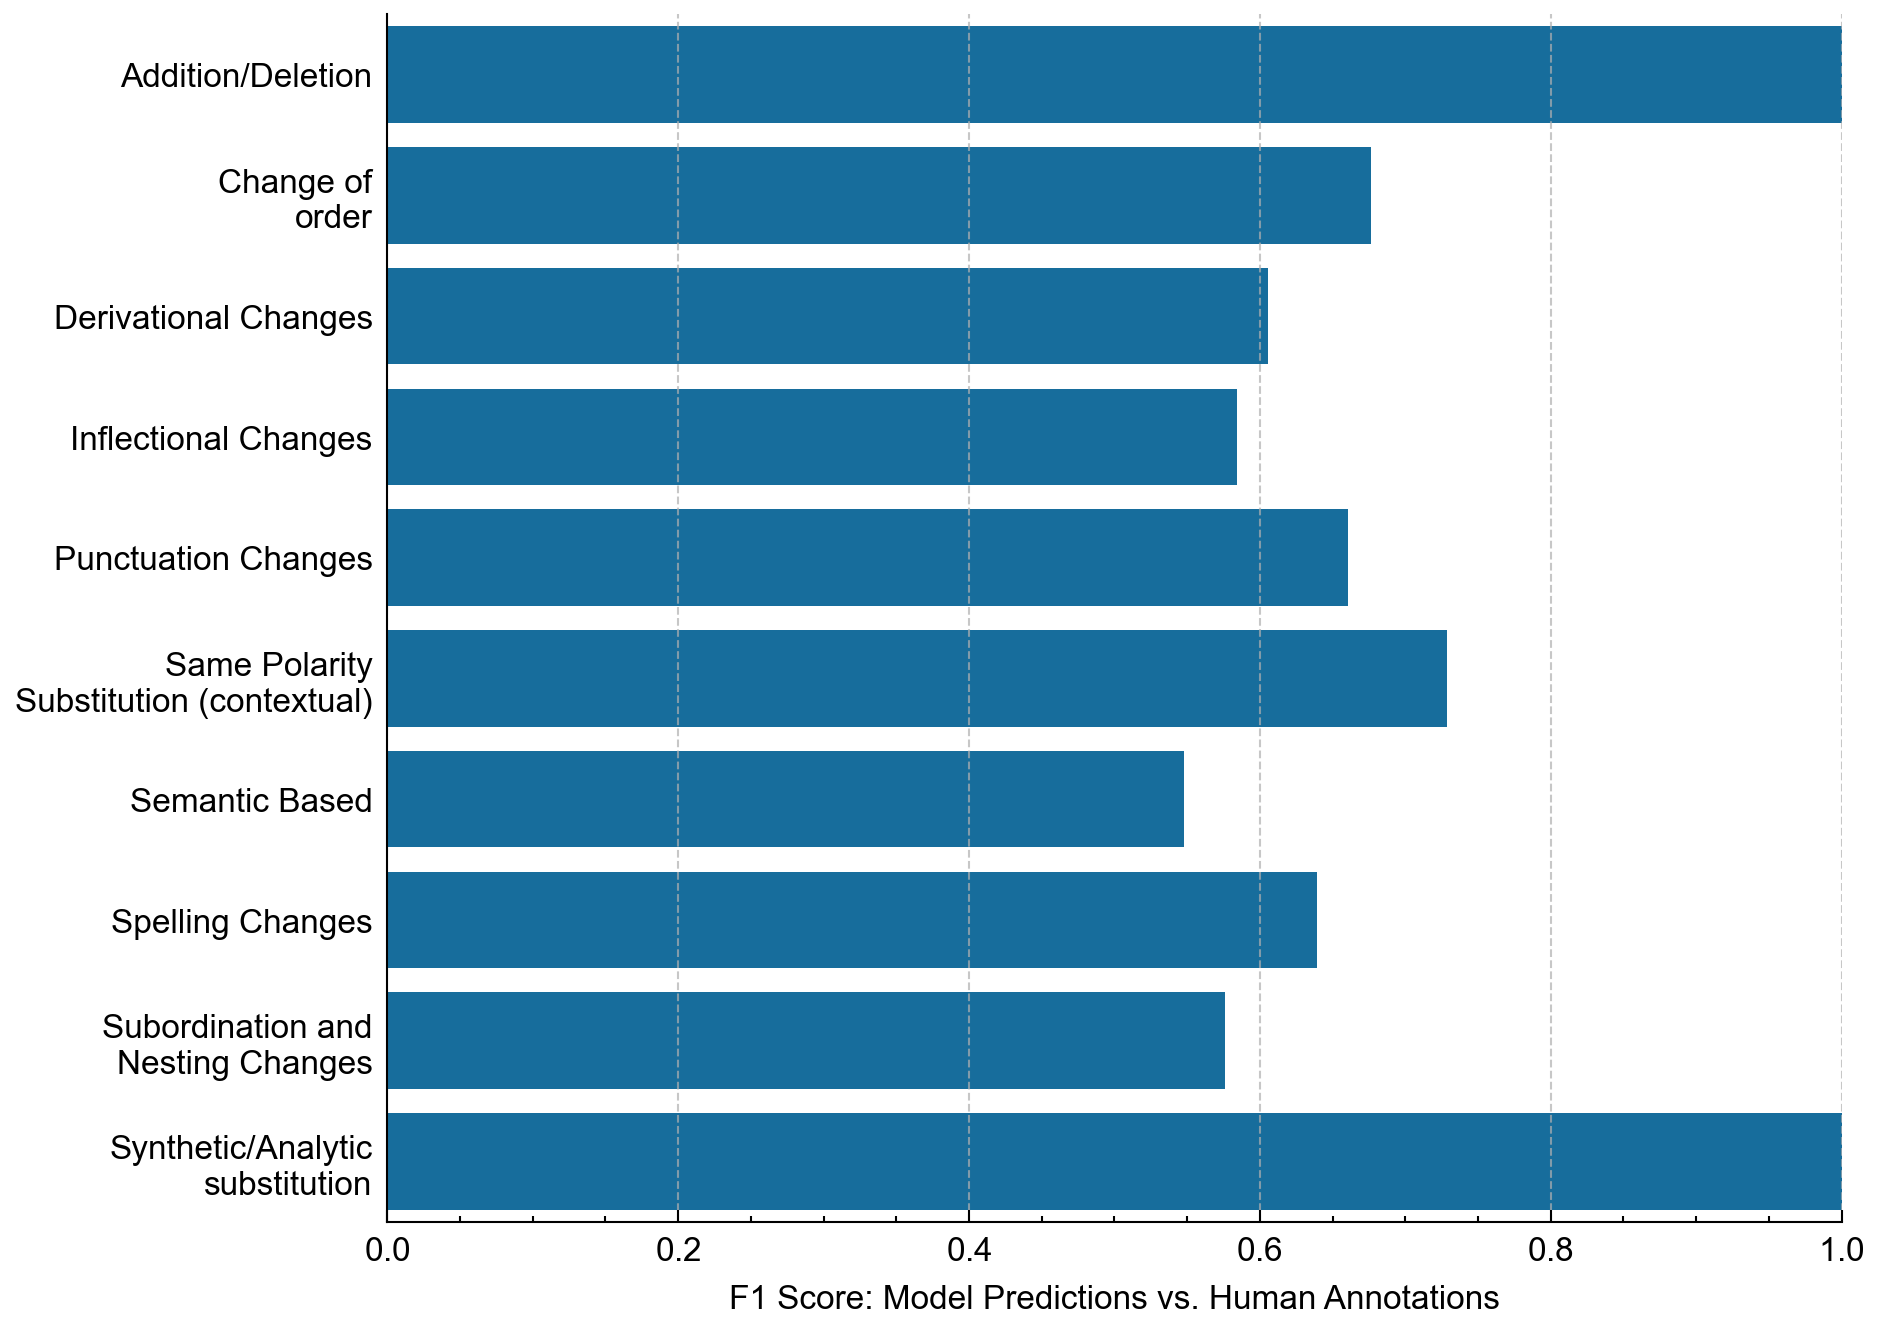

In [26]:
df_results["Paraphrase Type"] = (
    df_results["Paraphrase Type"]
    .map(PARAPHRASE_TYPE_MAPPING)
    .fillna(df_results["Paraphrase Type"])
)

df_results["Paraphrase Type"] = df_results["Paraphrase Type"].apply(
    lambda x: add_line_breaks(x, n=2)
)
df_results = df_results.sort_values(by="Paraphrase Type")

# Create a bar plot
fig, ax = plt.subplots(constrained_layout=True)

# Create the bar plot with updated model names
sns.barplot(
    data=df_results,
    y="Paraphrase Type",
    x="F1 Score",
)

# Customize the plot
ax.set_ylabel("")
ax.tick_params(
    axis="y", which="both", left=False, right=False
)  # Remove tick marks on the y-axis
plt.xlabel("F1 Score: Model Predictions vs. Human Annotations")
plt.xlim(0, 1)


plt.grid(axis="x", linestyle="--", alpha=0.7)


output_path = os.path.join(output_dir, "new_types.pdf")
plt.savefig(output_path, dpi=300)

### Llama-3.1


In [27]:
class ParaphraseTypeEvaluator:
    def __init__(self, model_name: str, top_k: int = 10):
        self.model_name = model_name
        self.top_k = top_k
        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name, local_files_only=True
        )
        self.tokenizer = AutoTokenizer.from_pretrained(
            model_name, clean_up_tokenization_spaces=True
        )
        self.model.eval()
        self.normalized_top_10_types = [
            ptype.strip().lower() for ptype in TOP_10_PARAPHRASE_TYPES
        ]

    def preprocess_apt(self, apt: str) -> List[str]:
        apt_types = apt.lower().split(", ")
        filtered_types = [
            ptype.strip()
            for ptype in apt_types
            if ptype.strip() in self.normalized_top_10_types
        ]
        return filtered_types

    def extract_paraphrase(self, paraphrase_list: List[str]) -> str:
        """Extracts the actual paraphrase text from the given list entry."""
        # Ensure the list has the expected structure and process the second element.
        if len(paraphrase_list) >= 2:
            paraphrase_entry = paraphrase_list[1]
            # Extract text after 'Generated Paraphrase:' and clean it up.
            match = re.search(
                r"Generated Paraphrase:(.*)", paraphrase_entry, re.IGNORECASE
            )
            if match:
                # Extract everything after 'Generated Paraphrase:'
                cleaned_paraphrase = match.group(1).strip()

                # If there are multiple numbered paraphrases, extract only the first one.
                # Look for "1." and "2."
                numbered_match = re.search(
                    r"1\.\s*(.*?)(?=\s*2\.)", cleaned_paraphrase, re.DOTALL
                )
                if numbered_match:
                    return numbered_match.group(1).strip()

                return cleaned_paraphrase
        return ""
    def predict_paraphrase_types(self, reference: str, paraphrase: str) -> List[str]:
        inputs = self.tokenizer(
            reference, paraphrase, truncation=True, max_length=256, return_tensors="pt"
        )
        with torch.no_grad():
            logits = self.model(**inputs).logits
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()

        top_k_indices = np.argsort(probs)[-self.top_k:][::-1]  # Descending order
        predicted_types = [
            TOP_10_PARAPHRASE_TYPES[idx].lower() for idx in top_k_indices if probs[idx] > 0.5
        ]
        return predicted_types

    def evaluate(self, json_file_path: str) -> pd.DataFrame:
        with open(json_file_path, "r", encoding="utf-8") as file:
            data = json.load(file)

        type_labels = {
            ptype.lower(): {"true_labels": [], "predicted_labels": []} 
            for ptype in TOP_10_PARAPHRASE_TYPES
        }

        for entry_idx, entry in enumerate(data):
            apt_type = entry['data'].get('APT', '').lower()
            if not apt_type:
                continue
            
            mapped_apt = PARAPHRASE_TYPE_MAPPING.get(apt_type, apt_type).lower()
            if mapped_apt not in type_labels:
                continue

            reference = entry['data'].get('Original', '')
            correct_model_ids = set()
            for annotation in entry['annotations']:
                for result in annotation['result']:
                    if result['from_name'] == 'annot':
                        ranker = result['value'].get('ranker', {})
                        for key in ['a', 'b']:
                            if key in ranker:
                                correct_model_ids.update(ranker[key])

            for model_id in ['0', '1', '2', '3']:
                model_output = next((item for item in entry['data']['List'] if str(item.get('id')) == model_id), None)
                true_label = 1 if model_id in correct_model_ids else 0
                
                if model_output and 'body' in model_output:
                    paraphrase = model_output['body'].split('\n')[0]  # Get first line of paraphrase
                    predicted_types = self.predict_paraphrase_types(reference, paraphrase)
                    pred_label = 1 if mapped_apt in predicted_types else 0

                else:
                    pred_label = 0
                    print(f"Model {model_id} - No output found")

                type_labels[mapped_apt]["true_labels"].append(true_label)
                type_labels[mapped_apt]["predicted_labels"].append(pred_label)

        results = []
        for ptype in TOP_10_PARAPHRASE_TYPES:
            ptype_lower = ptype.lower()
            true_labels = type_labels[ptype_lower]["true_labels"]
            pred_labels = type_labels[ptype_lower]["predicted_labels"]
            
            if true_labels:
                f1 = f1_score(true_labels, pred_labels, average="binary", zero_division=0)
            else:
                f1 = 0
            results.append({"Paraphrase Type": ptype, "F1 Score": f1})

        return pd.DataFrame(results)
    
# Initialize the evaluator
evaluator = ParaphraseTypeEvaluator(
    model_name="/home/slim/dpo-rhlf-paraphrase-types/out/cls-models/deberta-base_qqp_pd_etpc_ptd"
)

# Evaluate the data
df_project_6_results = evaluator.evaluate(
    json_file_path=annotation_file
)

# Map and format the paraphrase types
df_project_6_results["Paraphrase Type"] = (
    df_project_6_results["Paraphrase Type"]
    .map(PARAPHRASE_TYPE_MAPPING)
    .fillna(df_project_6_results["Paraphrase Type"])
)

df_project_6_results["Paraphrase Type"] = df_project_6_results["Paraphrase Type"].apply(
    lambda x: add_line_breaks(x, n=2)
)
df_project_6_results = df_project_6_results.sort_values(by="Paraphrase Type")



In [28]:
class ParaphraseTypeEvaluator:
    def __init__(self, model_name: str, top_k: int = 10):
        self.model_name = model_name
        self.top_k = top_k
        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name, local_files_only=True
        )
        self.tokenizer = AutoTokenizer.from_pretrained(
            model_name, clean_up_tokenization_spaces=True
        )
        self.model.eval()
        self.normalized_top_10_types = [
            ptype.strip().lower() for ptype in TOP_10_PARAPHRASE_TYPES
        ]

    def preprocess_apt(self, apt: str) -> List[str]:
        apt_types = apt.lower().split(", ")
        filtered_types = [
            ptype.strip()
            for ptype in apt_types
            if ptype.strip() in self.normalized_top_10_types
        ]
        return filtered_types

    def extract_paraphrase(self, paraphrase_list: List[str]) -> str:
        """Extracts the actual paraphrase text from the given list entry."""
        # Ensure the list has the expected structure and process the second element.
        if len(paraphrase_list) >= 2:
            paraphrase_entry = paraphrase_list[1]
            # Extract text after 'Generated Paraphrase:' and clean it up.
            match = re.search(
                r"Generated Paraphrase:(.*)", paraphrase_entry, re.IGNORECASE
            )
            if match:
                # Extract everything after 'Generated Paraphrase:'
                cleaned_paraphrase = match.group(1).strip()

                # If there are multiple numbered paraphrases, extract only the first one.
                # Look for "1." and "2."
                numbered_match = re.search(
                    r"1\.\s*(.*?)(?=\s*2\.)", cleaned_paraphrase, re.DOTALL
                )
                if numbered_match:
                    return numbered_match.group(1).strip()

                return cleaned_paraphrase
        return ""
    def predict_paraphrase_types(self, reference: str, paraphrase: str) -> List[str]:
        inputs = self.tokenizer(
            reference, paraphrase, truncation=True, max_length=256, return_tensors="pt"
        )
        with torch.no_grad():
            logits = self.model(**inputs).logits
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()

        top_k_indices = np.argsort(probs)[-self.top_k:][::-1]  # Descending order
        predicted_types = [
            TOP_10_PARAPHRASE_TYPES[idx].lower() for idx in top_k_indices if probs[idx] > 0.5
        ]
        return predicted_types

    def evaluate(self, json_file_path: str) -> pd.DataFrame:
        with open(json_file_path, "r", encoding="utf-8") as file:
            data = json.load(file)

        type_labels = {
            ptype.lower(): {"true_labels": [], "predicted_labels": []} 
            for ptype in TOP_10_PARAPHRASE_TYPES
        }
        
        for entry_idx, entry in enumerate(data):
            apt_type = entry['data'].get('APT', '').lower()
            if not apt_type:
                continue
            
            mapped_apt = PARAPHRASE_TYPE_MAPPING.get(apt_type, apt_type).lower()
            if mapped_apt not in type_labels:
                continue

            reference = entry['data'].get('Original', '')
            correct_model_ids = set()
            for annotation in entry['annotations']:
                for result in annotation['result']:
                    if result['from_name'] == 'annot':
                        ranker = result['value'].get('ranker', {})
                        for key in ['a', 'b']:
                            if key in ranker:
                                correct_model_ids.update(ranker[key])

            for model_id in ['0', '1', '2', '3']:
                model_output = next((item for item in entry['data']['List'] if str(item.get('id')) == model_id), None)
                true_label = 1 if model_id in correct_model_ids else 0
                
                if model_output and 'body' in model_output:
                    paraphrase = model_output['body'].split('\n')[0]  # Get first line of paraphrase
                    predicted_types = self.predict_paraphrase_types(reference, paraphrase)
                    pred_label = 1 if mapped_apt in predicted_types else 0

                else:
                    pred_label = 0
                    print(f"Model {model_id} - No output found")

                type_labels[mapped_apt]["true_labels"].append(true_label)
                type_labels[mapped_apt]["predicted_labels"].append(pred_label)

        results = []
        n_bootstrap = 1000
        alpha = 0.95  # 95% confidence interval
        
        for ptype in TOP_10_PARAPHRASE_TYPES:
            ptype_lower = ptype.lower()
            true_labels = type_labels[ptype_lower]["true_labels"]
            pred_labels = type_labels[ptype_lower]["predicted_labels"]
            
            if true_labels:
                # Calculate point estimate
                f1 = f1_score(true_labels, pred_labels, average="binary", zero_division=0)
                
                # Bootstrap confidence intervals
                bootstrap_f1s = []
                n_samples = len(true_labels)
                
                for _ in range(n_bootstrap):
                    # Sample with replacement
                    indices = np.random.randint(0, n_samples, n_samples)
                    bootstrap_true = np.array(true_labels)[indices]
                    bootstrap_pred = np.array(pred_labels)[indices]
                    
                    bootstrap_f1 = f1_score(bootstrap_true, bootstrap_pred, 
                                        average="binary", zero_division=0)
                    bootstrap_f1s.append(bootstrap_f1)
                
                # Calculate confidence intervals
                ci_lower = np.percentile(bootstrap_f1s, (1 - alpha) / 2 * 100)
                ci_upper = np.percentile(bootstrap_f1s, (1 + alpha) / 2 * 100)
            else:
                f1, ci_lower, ci_upper = 0, 0, 0
                
            results.append({
                "Paraphrase Type": ptype, 
                "F1 Score": f1,
                "CI_Lower": ci_lower,
                "CI_Upper": ci_upper
            })

        return pd.DataFrame(results)
    
# Initialize the evaluator
evaluator = ParaphraseTypeEvaluator(
    model_name="/home/slim/dpo-rhlf-paraphrase-types/out/cls-models/deberta-base_qqp_pd_etpc_ptd"
)

# Evaluate the data
df_project_6_results = evaluator.evaluate(
    json_file_path=annotation_file
)





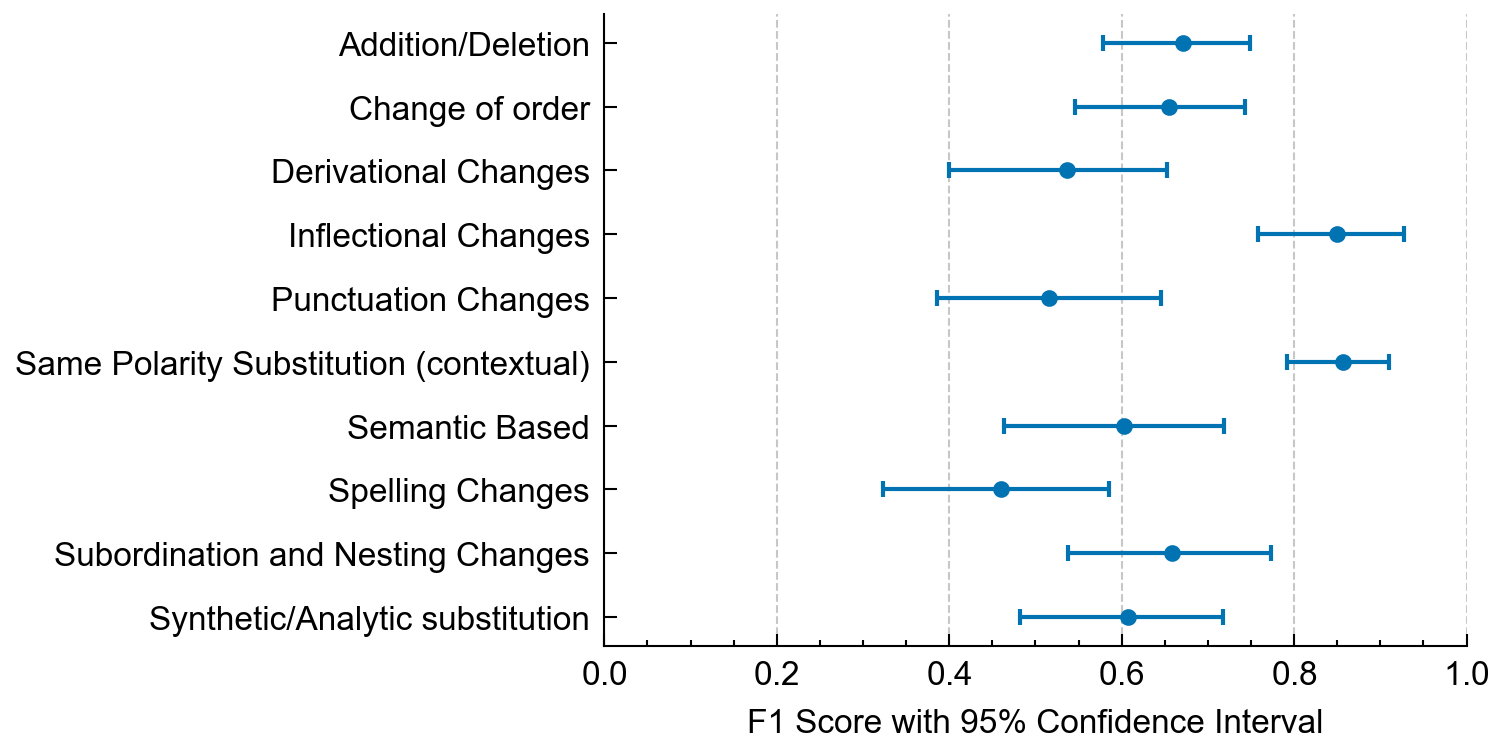

In [29]:
# Map and format the paraphrase types
df_project_6_results["Paraphrase Type"] = (
    df_project_6_results["Paraphrase Type"]
    .map(PARAPHRASE_TYPE_MAPPING)
    .fillna(df_project_6_results["Paraphrase Type"])
)

df_project_6_results["Paraphrase Type"] = df_project_6_results["Paraphrase Type"].apply(
    lambda x: add_line_breaks(x, n=2)
)
df_project_6_results = df_project_6_results.sort_values(by="Paraphrase Type", ascending=False)

# Create a bar plot
fig, ax = plt.subplots(constrained_layout=True, figsize=(5, 2.5))

# Create the bar plot with updated model names
ax.errorbar(
        y=range(len(df_project_6_results)),
        x=df_project_6_results['F1 Score'],
        xerr=[df_project_6_results['F1 Score'] - df_project_6_results['CI_Lower'], 
              df_project_6_results['CI_Upper'] - df_project_6_results['F1 Score']],
        fmt='o',
        capsize=2,
        capthick=1,
        elinewidth=1,
        markersize=3,
    )
    
    # Customize plot
ax.set_yticks(range(len(df_project_6_results)))
ax.set_yticklabels(df_project_6_results['Paraphrase Type'], ha='right')
ax.set_xlabel('F1 Score with 95% Confidence Interval')
ax.set_yticklabels(classes_sorted)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.grid(axis="y", linestyle="--", alpha=0)
ax.set_xlim(0, 1)
ax.tick_params(axis='y', which='minor', length=0)

# Save the plot
output_path = os.path.join(output_dir, "project_6_f1_scores.pdf")
plt.savefig(output_path, dpi=300)

## Broader NLP Task Improvements with Human-Ranked Data

In [30]:
from datasets import load_dataset, Features, Value
pd.set_option('display.max_rows', None)
from IPython.display import display

features = Features({
    'model': Value('string'),
    'base_model': Value('string'),
    'revision': Value('string'),
    'precision': Value('string'),
    'params': Value('float64'),
    'architectures': Value('string'),
    'weight_type': Value('string'),
    'status': Value('string'),
    'submitted_time': Value('string'),
    'model_type': Value('string'),
    'job_id': Value('string'),
    'job_start_time': Value('string'),
    'use_chat_template': Value('bool'),
    'sender': Value('string')
})


# dataset = load_dataset("open-llm-leaderboard/requests", split = "train", features=features)
# filtered_dataset = dataset.select_columns(["model", "status", "submitted_time", "revision", "job_start_time"]).filter(lambda x: "cluebbers" in x["model"] or "pending" in str(x["status"]).lower() or "running" in str(x["status"]).lower())
# filtered_dataset = filtered_dataset.sort("submitted_time")

# df = filtered_dataset.to_pandas()
# display(df)

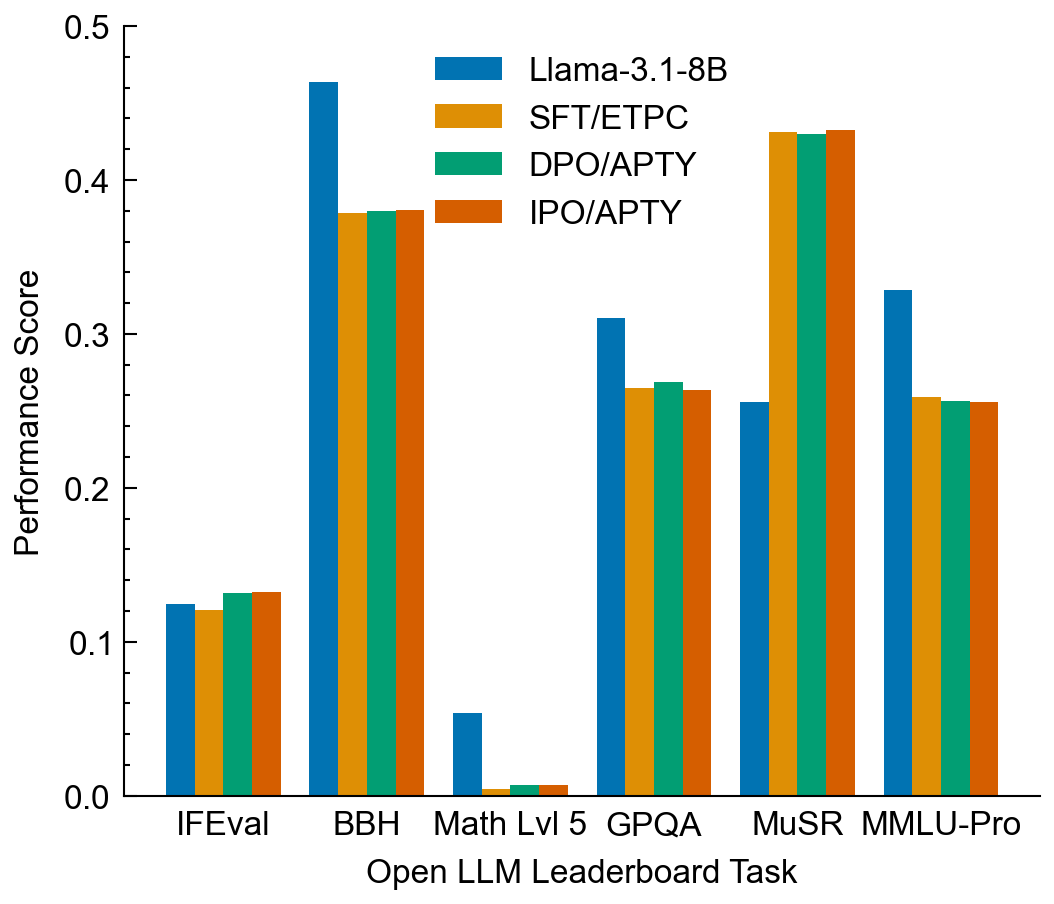

In [31]:
# Define tasks and models
tasks = ["IFEval", "BBH", "Math Lvl 5", "GPQA", "MuSR", "MMLU-Pro"]
models = ["Llama-3.1-8B", "SFT/ETPC", "DPO/APTY", "IPO/APTY"]
scores_data = {
    "IFEval": [
        0.1245983,
        0.1208516,
        0.1318424,
        0.1326669,
    ],  # Replace these with actual averages across paraphrase types
    "BBH": [0.463808, 0.378580, 0.379622, 0.380489],  # Replace zeros with actual scores
    "Math Lvl 5": [0.053625, 0.004532, 0.006798, 0.006798],
    "GPQA": [0.310403, 0.265101, 0.268456, 0.263423],
    "MuSR": [0.255568, 0.431217, 0.429894, 0.432540],
    "MMLU-Pro": [0.328790, 0.259059, 0.256233, 0.255568],
}

scores = pd.DataFrame(scores_data, index=models)

# Create a grouped bar chart
# Set figure size
fig, ax = plt.subplots(constrained_layout=True, figsize=(3.5, 3))

bar_width = 0.25  # Make bars thinner
group_spacing = 0.25  # Add space between groups
index = np.arange(len(tasks)) * (1 + group_spacing)  # Space out the groups more


# Plot bars for each model
for i, model in enumerate(models):
    ax.bar(index + i * bar_width, scores.iloc[i], bar_width, label=model)

# Set labels, title, and ticks
ax.set_xlabel("Open LLM Leaderboard Task")
ax.set_xticks(index + bar_width * (len(models) - 1) / 2)
ax.set_xticklabels(tasks)
ax.tick_params(axis="x", which="both", bottom=False, top=False)
# plt.xticks(rotation=45)
plt.ylim(0,0.5)
plt.grid(alpha=0)

ax.set_ylabel("Performance Score")
ax.legend()

output_path = os.path.join(output_dir, "llmboard.pdf")
plt.savefig(output_path, dpi=300)